In [15]:
import sys
sys.path.append('../')
import matplotlib.pyplot as plt
import numpy as np
import json
from qiskit.quantum_info import SparsePauliOp

In [16]:
# Extract classical results
cs_dir = "../classical_search/cs_res/"

def relabel_turns(turns: str) -> str:
    """Relabels the turns from the classical search to the ones used in the quantum search."""
    mapping = {
        "0": "0",
        "1": "2", 
        "2": "4",
        "3": "6",
        "4": "8",
        "5": "a",
        "6": "1",
        "7": "3",
        "8": "5",
        "9": "7",
        "a": "9",
        "b": "b"
    }
    return "".join([mapping[turn] for turn in turns])


def load_top_cls_solns(file_name: str) -> list:
    top_cls_turns = []
    with open(cs_dir + file_name, "r") as file:
        data = file.read()
        # Split by line
        data_by_line = data.split("\n")
        for line in data_by_line:
            if len(line.split("\t")) == 2:
                [energy, turns] = line.split("\t")
                top_cls_turns.append([relabel_turns(turns), float(energy)])
    return top_cls_turns

In [17]:
def convert_bitstring_to_turns(soln_bitstring: str, main_seq: str) -> str:
    """Converts a solution bitstring (given by the quantum algorithm) to the
    turns."""
    encoding = {
        "0000": "0",
        "0011": "1",
        "1100": "2",
        "1111": "3",
        "1001": "4",
        "0101": "5",
        "1010": "6",
        "0110": "7",
        "1000": "8",
        "0100": "9",
        "1011": "a",
        "0111": "b",
        "0001": "x", # unphysical
        "0010": "x", # unphysical
        "1101": "x", # unphysical
        "1110": "x", # unphysical
    }
    peptide_len = len(main_seq)
    config_bitstring = soln_bitstring[-(4 * peptide_len - 10) :]
    # Add the first 4 bits corresponding to the fixed first turn (0000)
    full_config_bitstring = config_bitstring + "0000"
    # Add the two qubits at positions 6 & 7 from the right (00)
    full_config_bitstring = (
        full_config_bitstring[:-6] + "00" + full_config_bitstring[-6:]
    )
    # Reverse the bitstring
    full_config_bitstring = full_config_bitstring[::-1]
    length_turns = len(full_config_bitstring) // 4
    turns = ""
    for i in range(length_turns):
        turn = full_config_bitstring[i * 4 : (i + 1) * 4]
        turns += encoding[turn]
    # Reverse the turns
    return turns[::-1]

### KLVFFA_6AAs MPS run
- $R^2 = 1$
- 100k shots
- 500 COBYLA iterations

In [18]:
import os
import json

# Update to full absolute paths
base_paths = {
    1: "/home/hakan-doga/data/protein-folding-qc/res/fcc_hw/KLVFFA_2025-05-23-16-17-46_aer_simulator_matrix_product_state_interval1",
    2: "/home/hakan-doga/data/protein-folding-qc/res/fcc_hw/KLVFFA_2025-05-23-16-17-46_aer_simulator_matrix_product_state_interval2",
    3: "/home/hakan-doga/data/protein-folding-qc/res/fcc_hw/KLVFFA_2025-05-24-16-44-24_aer_simulator_matrix_product_state_interval3",
    4: "/home/hakan-doga/data/protein-folding-qc/res/fcc_hw/KLVFFA_2025-05-24-16-44-24_aer_simulator_matrix_product_state_interval4"
}

# Load metadata and opt_results
all_metadata = {}
all_opt_results = {}

for i in range(1, 5):
    res_dir = base_paths[i]
    metadata_path = os.path.join(res_dir, "metadata.json")
    opt_res_path = os.path.join(res_dir, "opt_results.json")

    if not os.path.exists(metadata_path):
        raise FileNotFoundError(f"Metadata file not found at: {metadata_path}")
    if not os.path.exists(opt_res_path):
        raise FileNotFoundError(f"Results file not found at: {opt_res_path}")

    with open(metadata_path, "r") as f:
        all_metadata[i] = json.load(f)

    with open(opt_res_path, "r") as f:
        all_opt_results[i] = json.load(f)

print("✅ Loaded metadata and optimization results for all 4 intervals.")


✅ Loaded metadata and optimization results for all 4 intervals.


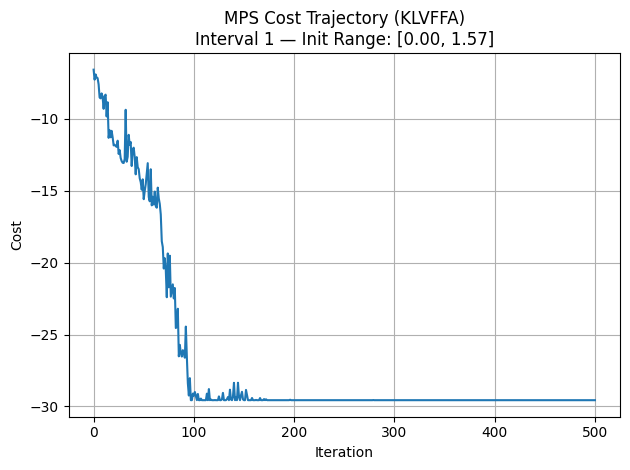

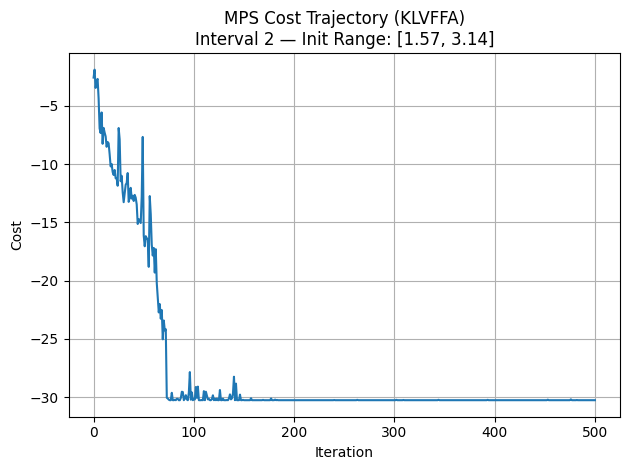

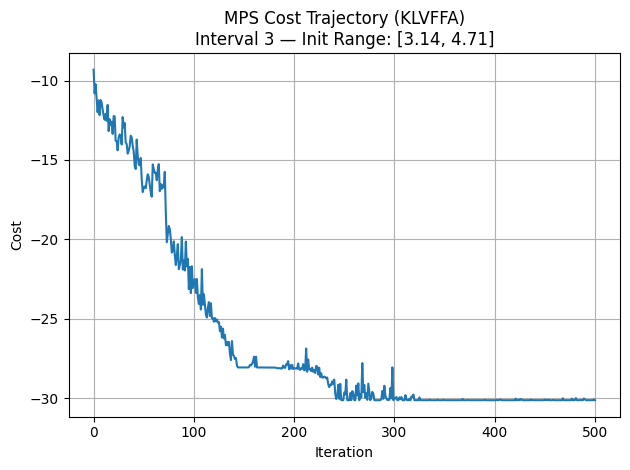

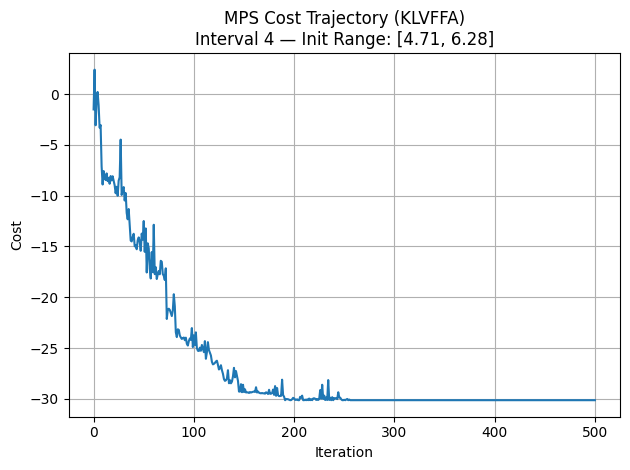

In [19]:
import matplotlib.pyplot as plt

# Plotting cost trajectories for each interval
for i in range(1, 5):
    opt_res = all_opt_results[i]
    metadata = all_metadata[i]

    plt.figure()
    plt.plot(opt_res["cost_trajectory"])
    plt.xlabel("Iteration")
    plt.ylabel("Cost")
    plt.title(f"MPS Cost Trajectory (KLVFFA)\nInterval {i} — Init Range: {metadata['init_param_interval']}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [20]:
# Dictionary to store top 100 solutions per interval
top_mps_solns_by_interval = {}

for i in range(1, 5):
    opt_res = all_opt_results[i]
    metadata = all_metadata[i]

    # Extract top 100 solutions
    top_100 = opt_res["top_solutions"][:100]

    # Convert to [turn_seq, bitstring, energy] format
    top_mps_solns = [
        [convert_bitstring_to_turns(bitstring, metadata["main_seq"]), bitstring, energy]
        for bitstring, energy in top_100
    ]

    # Store
    top_mps_solns_by_interval[i] = top_mps_solns

# Preview the first few entries from interval 1
top_mps_solns_by_interval[1][:10]


[['9a180', '001111101000101101110001', -30.425689245042722],
 ['68b90', '110110011101010001111010', -30.252008372907074],
 ['02180', '010111011000000011110001', -30.22919311159673],
 ['7b090', '001111100101101110000010', -29.563373108996682],
 ['30720', '001111001011110000011011', -29.123196275576888],
 ['1b090', '011011100111001110000010', -28.68834024144333],
 ['8b090', '001111000100011110000010', -28.25800352499234],
 ['7b090', '001111000101101110000010', -28.25337310899668],
 ['3a490', '001111000111111101100110', -28.251547002659834],
 ['8a490', '001111000100011101100110', -28.24699627798107]]

In [21]:
for i in range(1, 5):
    top_mps_solns = top_mps_solns_by_interval[i]
    
    # Convert each turn sequence (a list) to a tuple so it can go in a set
    unique_turns = set(tuple(sol[0]) for sol in top_mps_solns)
    
    print(f"Interval {i} — Init Range {all_metadata[i]['init_param_interval']}: {len(unique_turns)} unique turn sequences")



Interval 1 — Init Range [0.00, 1.57]: 60 unique turn sequences
Interval 2 — Init Range [1.57, 3.14]: 41 unique turn sequences
Interval 3 — Init Range [3.14, 4.71]: 66 unique turn sequences
Interval 4 — Init Range [4.71, 6.28]: 51 unique turn sequences


In [22]:
# Get top 100 solutions from classical search results
top_cls_solns = load_top_cls_solns(f"{len(metadata['main_seq'])}AA_{metadata['main_seq']}_topobj.txt")[:100]
top_cls_solns[:10]

[['97490', -30.57],
 ['a9720', -30.55],
 ['8b520', -30.55],
 ['70b90', -30.45],
 ['81490', -30.45],
 ['31a20', -30.43],
 ['31820', -30.43],
 ['2b580', -30.43],
 ['9a180', -30.43],
 ['5b580', -30.33]]

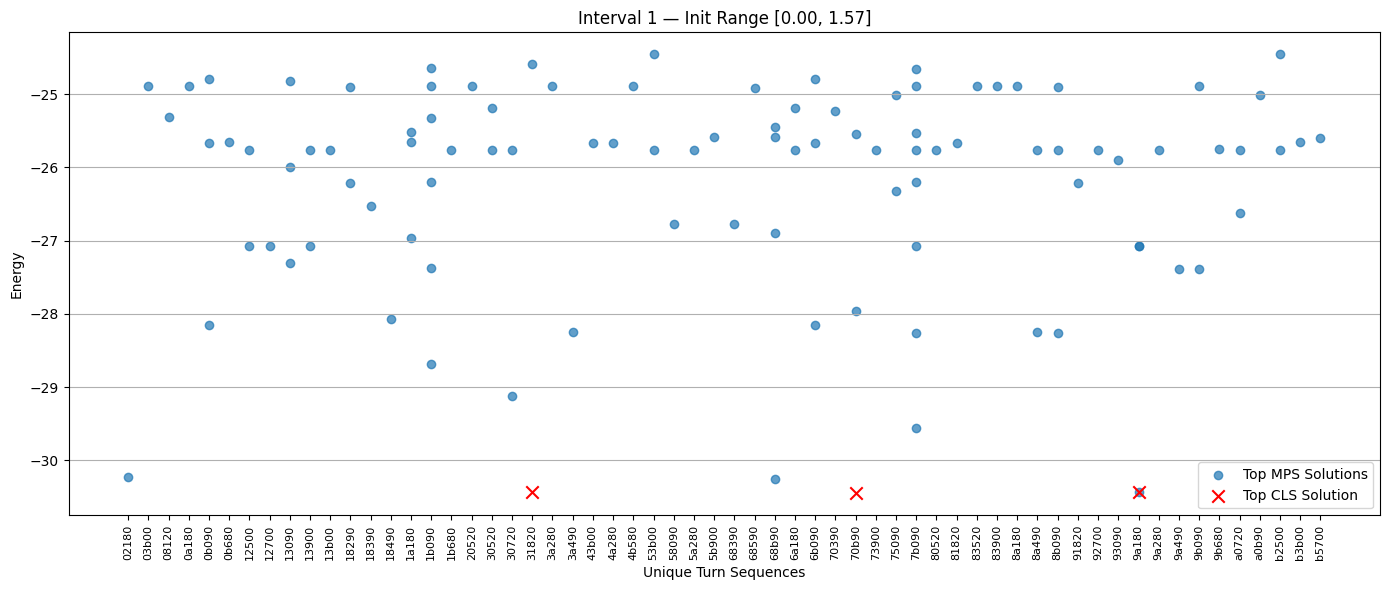

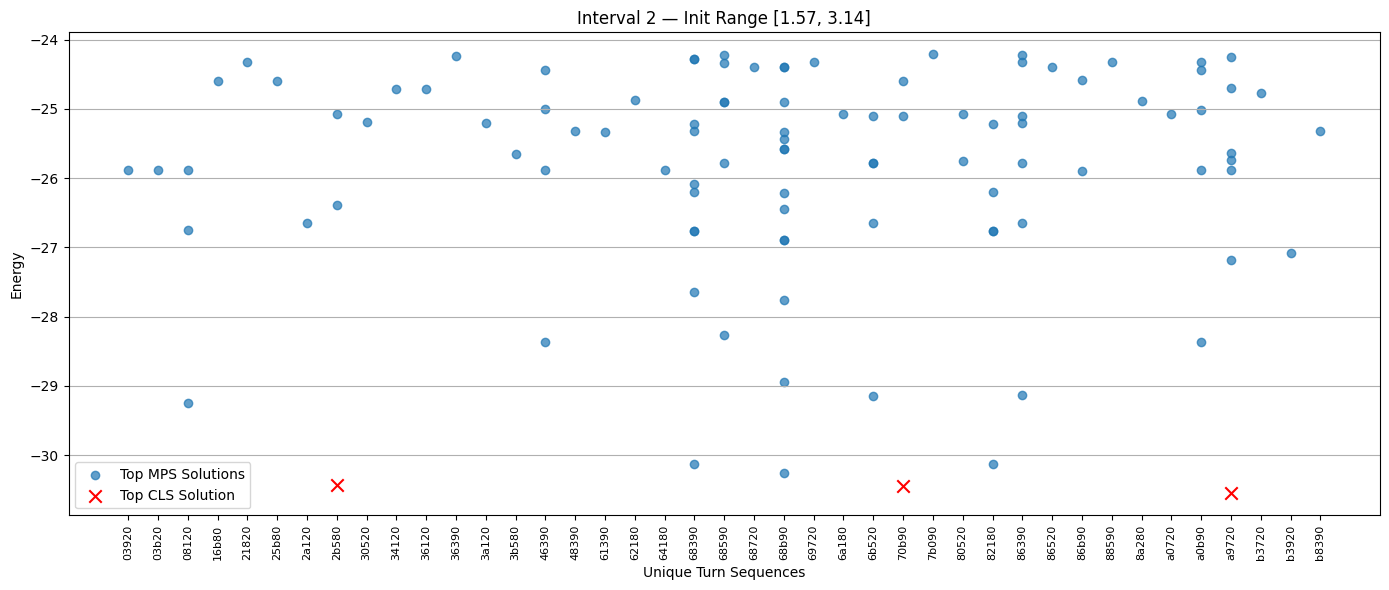

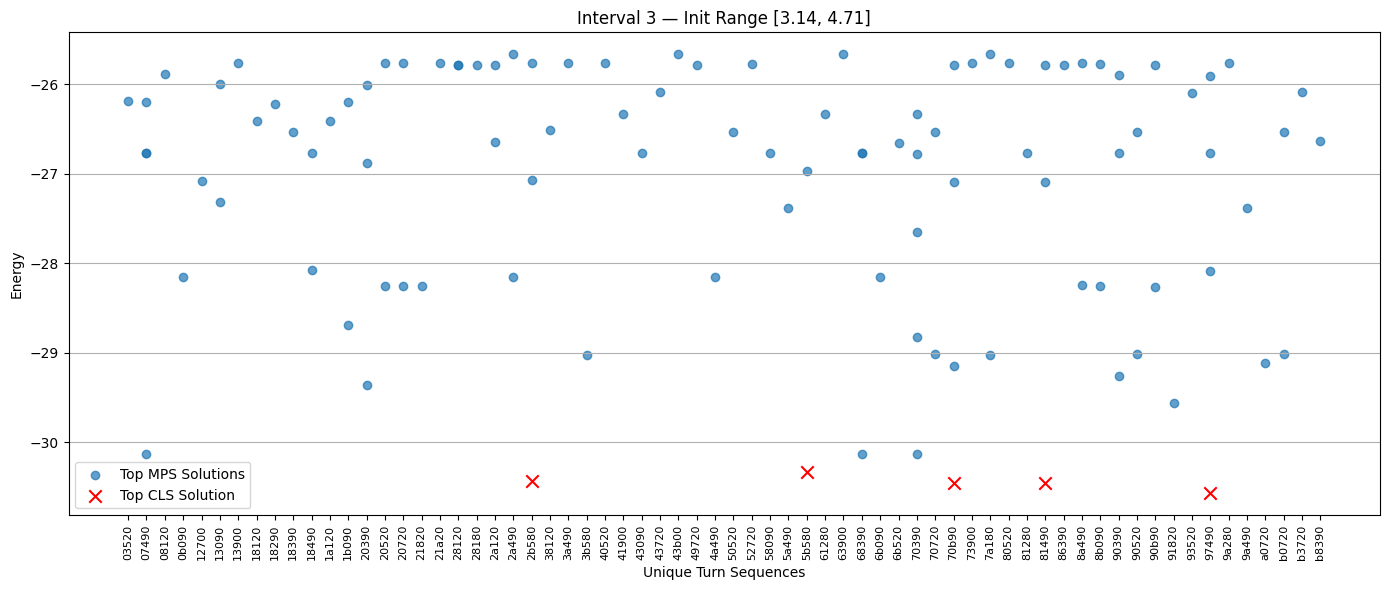

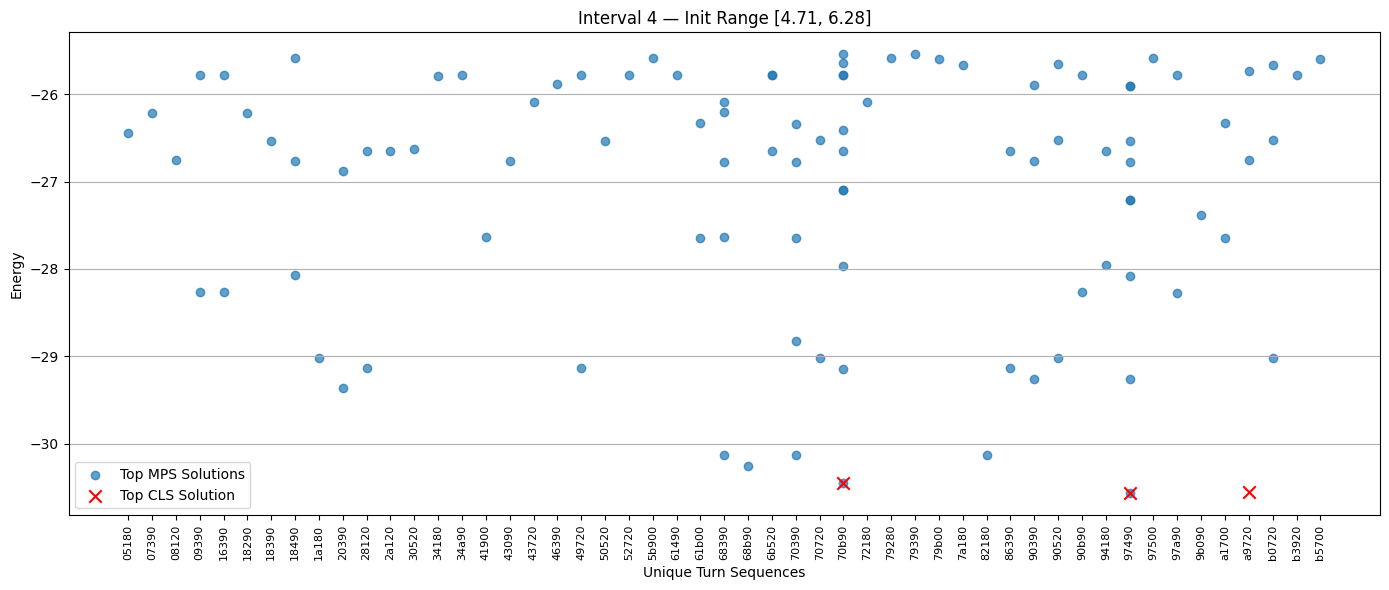

In [24]:
from collections import defaultdict
import matplotlib.pyplot as plt

# Extract only top 10 CLS turns as strings
top_cls_turns = {sol[0] for sol in top_cls_solns[:10]}

for i in range(1, 5):
    top_mps_solns = top_mps_solns_by_interval[i]
    metadata = all_metadata[i]
    
    turn_seq_energy_dict = defaultdict(list)
    for turn_seq, bitstring, energy in top_mps_solns:
        turn_str = ''.join(turn_seq)
        turn_seq_energy_dict[turn_str].append(energy)

    sorted_turns = sorted(turn_seq_energy_dict.keys())
    
    x_vals, y_vals = [], []
    for idx, turn in enumerate(sorted_turns):
        energies = turn_seq_energy_dict[turn]
        x_vals.extend([idx] * len(energies))
        y_vals.extend(energies)
    
    turn_seq_to_index = {turn_seq: idx for idx, turn_seq in enumerate(sorted_turns)}

    plt.figure(figsize=(14, 6))
    plt.scatter(x_vals, y_vals, alpha=0.7, label='Top MPS Solutions')

    # Overlay red x's for top 10 CLS if they exist in MPS
    cls_label_used = False
    for turn_str in top_cls_turns:
        energy = next((e for t, e in top_cls_solns if t == turn_str), None)
        if energy is None:
            continue
        if turn_str in turn_seq_to_index:
            x_idx = turn_seq_to_index[turn_str]
            plt.scatter(
                x_idx,
                energy,
                color='red',
                marker='x',
                s=80,
                label='Top CLS Solution' if not cls_label_used else ""
            )
            cls_label_used = True

    plt.xticks(ticks=range(len(sorted_turns)), labels=sorted_turns, rotation=90, fontsize=8)
    plt.xlabel("Unique Turn Sequences")
    plt.ylabel("Energy")
    plt.title(f"Interval {i} — Init Range {metadata['init_param_interval']}")
    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.legend()
    plt.show()


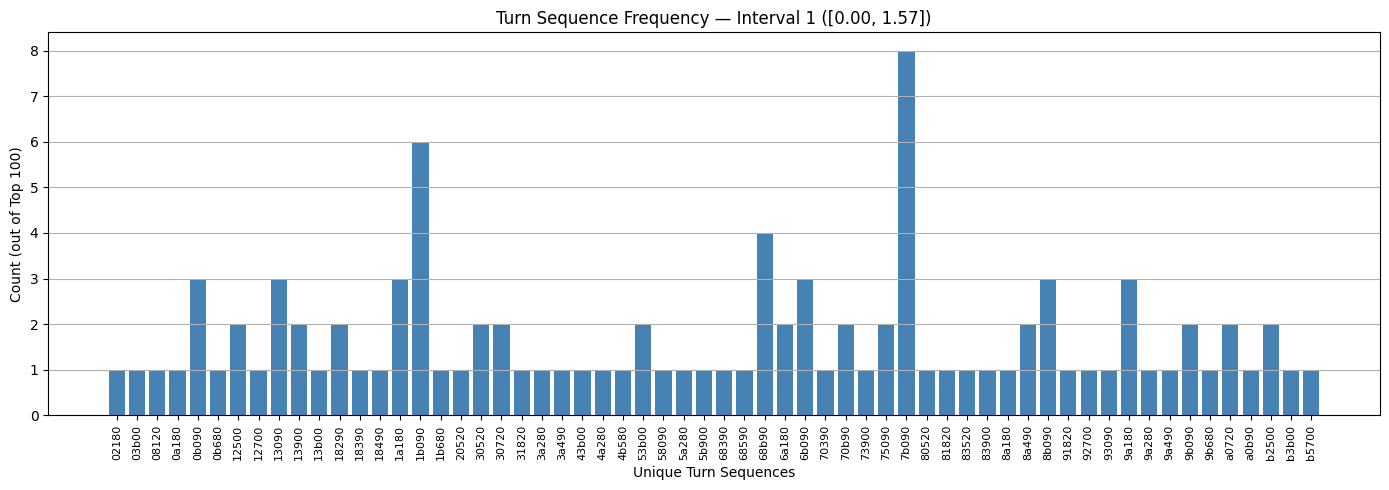

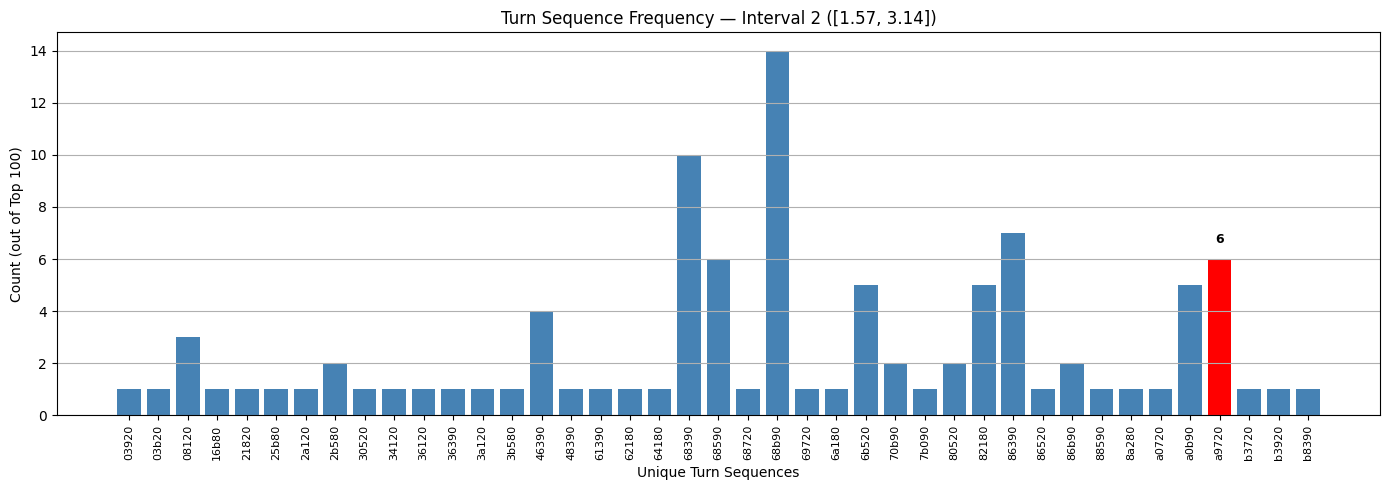

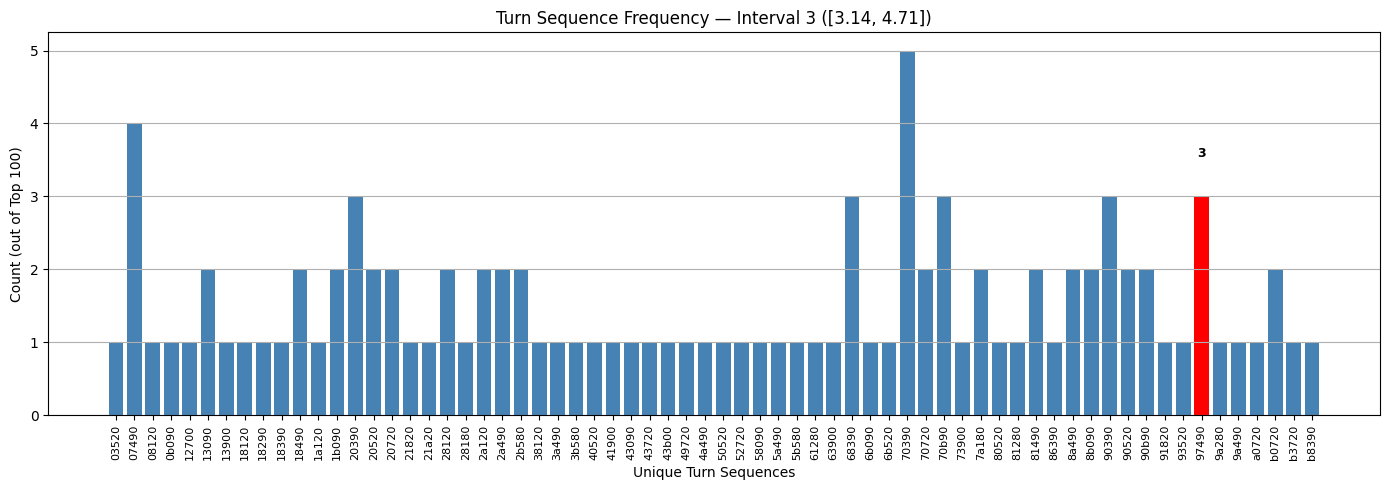

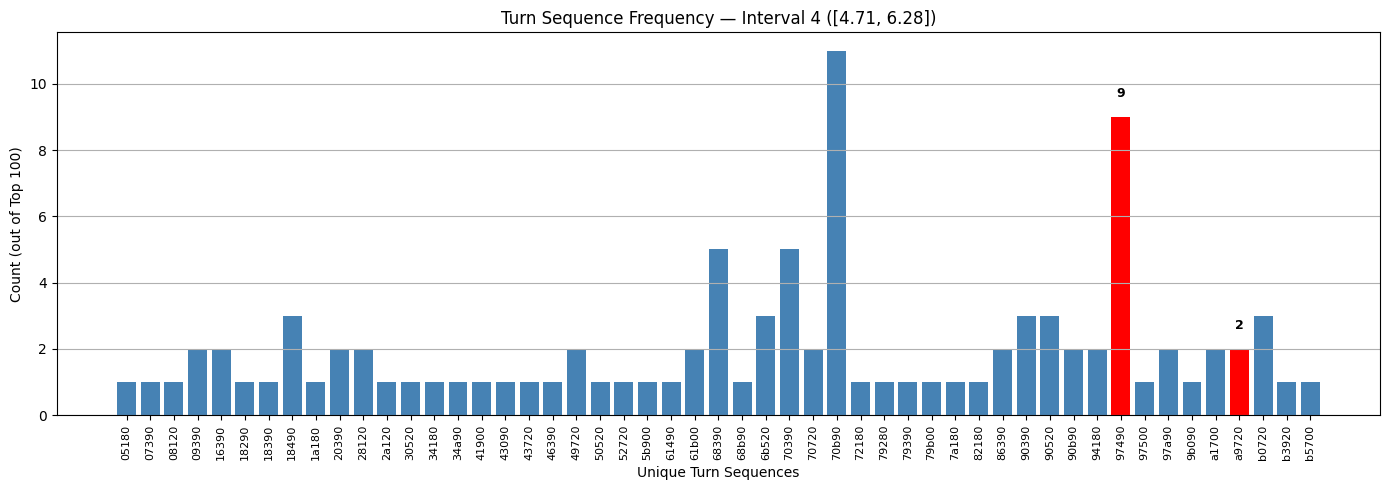

In [25]:
from collections import Counter
import matplotlib.pyplot as plt

# Top 3 classical solutions to highlight
cls_top3 = {'97490', 'a9720', '8b520'}

for i in range(1, 5):
    top_mps_solns = top_mps_solns_by_interval[i]
    metadata = all_metadata[i]
    
    # Extract turn sequences as strings
    turn_strs = [''.join(sol[0]) for sol in top_mps_solns]
    
    # Count occurrences
    turn_counts = Counter(turn_strs)
    sorted_turns = sorted(turn_counts.keys())
    
    x_vals = list(range(len(sorted_turns)))
    y_vals = [turn_counts[turn] for turn in sorted_turns]
    
    # Color bars: red for top-3 CLS, blue otherwise
    bar_colors = ['red' if turn in cls_top3 else 'steelblue' for turn in sorted_turns]
    
    # Plot
    plt.figure(figsize=(14, 5))
    bars = plt.bar(x_vals, y_vals, color=bar_colors)
    
    # Annotate red bars with count
    for idx, turn in enumerate(sorted_turns):
        if turn in cls_top3:
            count = turn_counts[turn]
            plt.text(x_vals[idx], y_vals[idx] + 0.5, str(count), ha='center', va='bottom', color='black', fontsize=9, fontweight='bold')
    
    plt.xticks(ticks=x_vals, labels=sorted_turns, rotation=90, fontsize=8)
    plt.xlabel("Unique Turn Sequences")
    plt.ylabel("Count (out of Top 100)")
    plt.title(f"Turn Sequence Frequency — Interval {i} ({metadata['init_param_interval']})")
    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.show()
